<div dir="rtl">

# **اسم الطالب /أنس محمد عبد الجليل سعيد**

## فكرة المشروع:
# **نظام ذكي لاكتشاف وتصنيف الهجمات الشبكية باستخدام تعلم الآلة (Intelligent Network Intrusion Detection System Using Machine Learning)**

### وصف المشروع:

يهدف المشروع إلى بناء نظام يعتمد على **Machine Learning** لتحليل حركة مرور الشبكة واكتشاف الهجمات الإلكترونية وتصنيف نوع الهجوم تلقائيًا باستخدام خوارزمية **Random Forest Classifier**.

يقوم النظام باستقبال خصائص الاتصال الشبكي (Network Traffic Features) مثل:

* مدة الاتصال (`dur`)
* عدد الحزم المرسلة والمستقبلة (`spkts`, `dpkts`)
* حجم البيانات (`sbytes`, `dbytes`)
* البروتوكول المستخدم (`proto`)
* حالة الاتصال (`state`)
* نوع الخدمة (`service`)


## أهداف المشروع:

* بناء نموذج ذكاء اصطناعي لاكتشاف التهديدات الأمنية.
* تصنيف حركة الشبكة إلى أنواع مختلفة من الهجمات.
* مقارنة أداء النموذج باستخدام مقاييس التقييم.
* إنشاء نظام يمكن استخدامه للتنبؤ بهجمات جديد
## رابط المشروع على
* coogle colabhttps://colab.research.google.com/drive/1D76qPdJSUjejp8tni_uFLsrZH2HvWfaT?usp=sharing

</div>

# <span style="color:red;">  المرحلة الاولى : التجهيز والتحميل</span>

 اولا: استيراد المكاتب اللازمة

In [2]:
import numpy as np  # مكتبة العمليات الحسابية والمصفوفات
import pandas as pd  # مكتبة معالجة وتحليل البيانات
import matplotlib.pyplot as plt  # مكتبة رسم المخططات البيانية
import seaborn as sns  # مكتبة رسم البيانات بشكل متقدم

from sklearn.model_selection import train_test_split  # تقسيم البيانات إلى تدريب واختبار
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder  # تحويل البيانات النصية إلى رقمية
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # توحيد وتطبيع قيم البيانات

from sklearn.ensemble import RandomForestClassifier  # استيراد خوارزمية الغابة العشوائية للتصنيف

from sklearn.metrics import f1_score, confusion_matrix, accuracy_score, precision_score, recall_score, classification_report  # مقاييس تقييم أداء النموذج

import joblib  # حفظ وتحميل نماذج التعلم الآلي

<!-- ### <span style="color:red">تحميل البيانات  </span> -->
ثانيا:تحميل مجموعة البيانات

In [3]:

dataset=pd.read_csv("UNSW_NB15.csv")
dataset.drop("label",axis=1,inplace=True)

 ثالثا: عرض جزاء من البيانات مثلا عرض اول 5 صفوف *  

In [4]:
print(dataset.shape)  # عرض عدد الصفوف والأعمدة في مجموعة البيانات
print(" عرض اول 5 صفوف ")  # طباعة عنوان عرض البيانات الأولى
display(dataset.head())  # عرض أول 5 سجلات من البيانات
print("_"*100)  # طباعة خط فاصل لتنظيم المخرجات
print(" عرض اخر 5 صفوف ")  # طباعة عنوان عرض البيانات الأخيرة
display(dataset.tail())  # عرض آخر 5 سجلات من البيانات
print("_"*100)  # طباعة خط فاصل لتنظيم المخرجات

(257673, 43)
 عرض اول 5 صفوف 


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,...,1,1,1,0,0,0,1,1,0,Normal
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,...,1,1,2,0,0,0,1,6,0,Normal
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,...,1,1,3,0,0,0,2,6,0,Normal
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,...,1,1,3,1,1,0,2,1,0,Normal
4,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,...,2,1,40,0,0,0,2,39,0,Normal


____________________________________________________________________________________________________
 عرض اخر 5 صفوف 


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
257668,0.000005,udp,-,INT,2,0,104,0,200000.005100,254,...,1,1,2,0,0,0,2,1,0,Normal
257669,1.106101,tcp,-,FIN,20,8,18062,354,24.410067,254,...,1,1,1,0,0,0,3,2,0,Normal
257670,0.000000,arp,-,INT,1,0,46,0,0.000000,0,...,1,1,1,0,0,0,1,1,1,Normal
257671,0.000000,arp,-,INT,1,0,46,0,0.000000,0,...,1,1,1,0,0,0,1,1,1,Normal
257672,0.000009,udp,-,INT,2,0,104,0,111111.107200,254,...,1,1,1,0,0,0,1,1,0,Normal


____________________________________________________________________________________________________


### رابعا:معلومات عامة عن البانات

In [5]:
print(dataset.info())
print("_"*100)

<class 'pandas.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 43 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                257673 non-null  float64
 1   proto              257673 non-null  str    
 2   service            257673 non-null  str    
 3   state              257673 non-null  str    
 4   spkts              257673 non-null  int64  
 5   dpkts              257673 non-null  int64  
 6   sbytes             257673 non-null  int64  
 7   dbytes             257673 non-null  int64  
 8   rate               257673 non-null  float64
 9   sttl               257673 non-null  int64  
 10  dttl               257673 non-null  int64  
 11  sload              257673 non-null  float64
 12  dload              257673 non-null  float64
 13  sloss              257673 non-null  int64  
 14  dloss              257673 non-null  int64  
 15  sinpkt             257673 non-null  float64
 16  dinpkt       

### خامسا:احصائيات البيانات الوصفية والرقمية

In [6]:
# احصائيات البيانات الرقمية
print("احصائيات البيانات الرقمية")
display(dataset.describe())
print("_"*100)
#احصائيات البيانات النصية
print("احصائيات البيانات النصية")
display(dataset.describe(include="object"))
print("_"*100)

احصائيات البيانات الرقمية


,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
count,257673.000000,257673.000000,257673.000000,2.576730e+05,2.576730e+05,2.576730e+05,257673.000000,257673.000000,2.576730e+05,2.576730e+05,...,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000
mean,1.246715,19.777144,18.514703,8.572952e+03,1.438729e+04,9.125391e+04,180.000931,84.754957,7.060869e+07,6.582143e+05,...,6.050467,5.238271,4.032677,8.322964,0.012819,0.012850,0.132005,6.800045,9.121049,0.014274
std,5.974305,135.947152,111.985965,1.737739e+05,1.461993e+05,1.603446e+05,102.488268,112.762131,1.857313e+08,2.412372e+06,...,8.173749,8.160822,5.831515,11.120754,0.116091,0.116421,0.681854,8.396266,10.874752,0.118618
min,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.078928e+01,62.000000,0.000000,1.231800e+04,0.000000e+00,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000
50%,0.004285,4.000000,2.000000,5.280000e+02,1.780000e+02,2.955665e+03,254.000000,29.000000,7.439423e+05,1.747441e+03,...,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000
75%,0.685777,12.000000,10.000000,1.362000e+03,1.064000e+03,1.250000e+05,254.000000,252.000000,8.000000e+07,2.210538e+04,...,6.000000,4.000000,3.000000,8.000000,0.000000,0.000000,0.000000,8.000000,11.000000,0.000000
max,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,2.242273e+07,...,59.000000,59.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000


____________________________________________________________________________________________________
احصائيات البيانات النصية


C:\Users\a\AppData\Local\Temp\ipykernel_22732\1999237643.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(dataset.describe(include="object"))


,proto,service,state,attack_cat
count,257673,257673,257673,257673
unique,133,13,11,10
top,tcp,-,FIN,Normal
freq,123041,141321,117164,93000


____________________________________________________________________________________________________


### سادسا:حجم البيانات او ابعاد البيانات

In [7]:
# اجاد ابعاد البيانات
print("ابعاد البيانات\n","data shape :",dataset.shape)
print("_"*100)

ابعاد البيانات
 data shape : (257673, 43)
____________________________________________________________________________________________________


### <span style="color:red">المرحلة الثانية:فحص وتنظيف البيانات</span>

### اولا:التحقق من القيم المفقودة

In [8]:
print(":التحقق من القيم الفرغة  \n",dataset.isnull().sum())
print("_"*100)

:التحقق من القيم الفرغة  
 dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_

### ثانيا:التحقق من التكرارات

In [9]:
# اجاد عدد الصفوف المكررة في مجموعة البيانات
print("عددالصفوف المكررة:؟",dataset.duplicated().sum())

عددالصفوف المكررة:؟ 94928


### ثالثا:التحقق من القيم المتطرفة

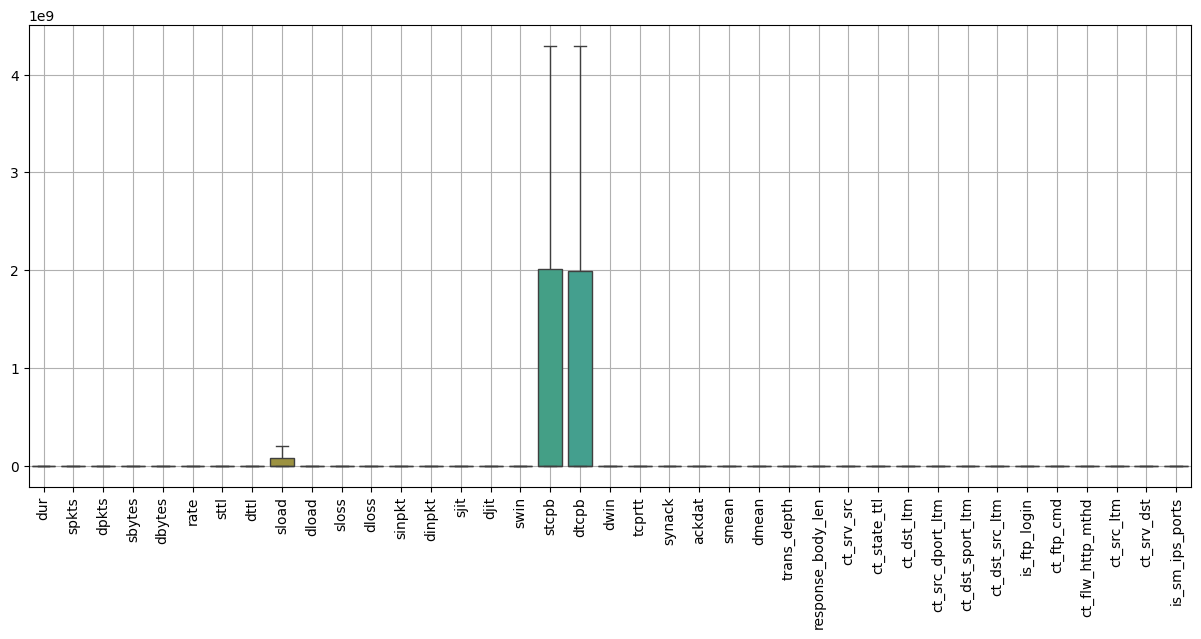

In [10]:
# حذف الأعمدة التي تحتوي على قيم غير رقمية أو مشاكل
numeric_data = dataset.apply(pd.to_numeric, errors='coerce')

# حذف الأعمدة الفارغة بالكامل
numeric_data = numeric_data.dropna(axis=1, how='all')

plt.figure(figsize=(15,6))

sns.boxplot(data=numeric_data, showfliers=False)

plt.xticks(rotation=90)
plt.grid()
plt.show()

In [11]:
# استخراج الأعمدة الرقمية فقط من مجموعة البيانات
data = dataset.select_dtypes(include=[np.number])

# حساب الربع الأول (Q1) لكل عمود
Q1 = data.quantile(0.25)

# حساب الربع الثالث (Q3) لكل عمود
Q3 = data.quantile(0.75)

# حساب المدى الربيعي (Interquartile Range - IQR)
IQR = Q3 - Q1

# حساب عدد القيم الشاذة (Outliers) في كل عمود
# تعتبر القيمة شاذة إذا كانت أقل من (Q1 - 1.5 × IQR)
# أو أكبر من (Q3 + 1.5 × IQR)
outlier_count = (
    (data < (Q1 - 1.5 * IQR)) |
    (data > (Q3 + 1.5 * IQR))
).sum()

# عرض عدد القيم الشاذة في كل عمود
print(outlier_count)

dur                  21597
spkts                34871
dpkts                29737
sbytes               32164
dbytes               40024
rate                 23541
sttl                     0
dttl                     0
sload                22034
dload                57556
sloss                16966
dloss                39660
sinpkt               20319
dinpkt               17588
sjit                 23533
djit                 29010
swin                     0
stcpb                    0
dtcpb                    0
dwin                     0
tcprtt               12442
synack               21327
ackdat                8557
smean                32653
dmean                33189
trans_depth          25422
response_body_len    16951
ct_srv_src           28068
ct_state_ttl          3763
ct_dst_ltm           42388
ct_src_dport_ltm     49014
ct_dst_sport_ltm     48244
ct_dst_src_ltm       43419
is_ftp_login          3245
ct_ftp_cmd            3247
ct_flw_http_mthd     25420
ct_src_ltm           28194
c

### رابعا:حذف الصفوف المكررة

In [12]:
#حذف الصفوف المكررة في البيانات
print("البيانات قبل الحذف \n",dataset.shape)
dataset=dataset.drop_duplicates()
print("_"*100)
# التاكد بعد حذف الصفوف
print("البيانات بعد الحذف\n",dataset.shape)
print("_"*100)

البيانات قبل الحذف 
 (257673, 43)
____________________________________________________________________________________________________
البيانات بعد الحذف
 (162745, 43)
____________________________________________________________________________________________________


### ثانيا:توزيع بيانات الهدف

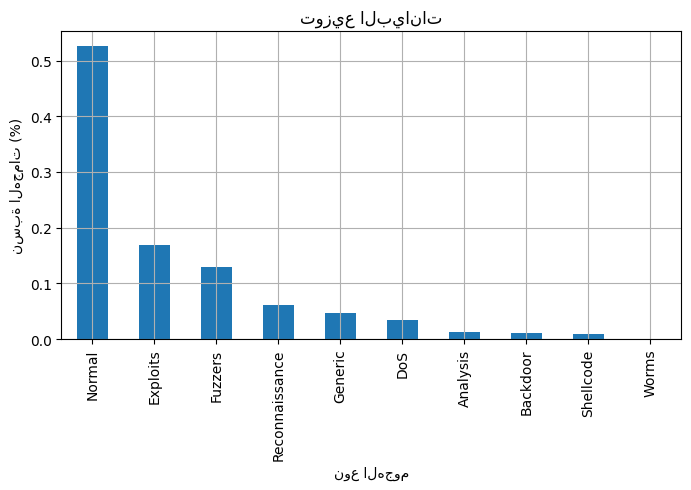

In [13]:
# رسم مخطط يوضح توزيع أنواع الهجمات داخل مجموعة البيانات
# يساعد على معرفة عدد العينات الموجودة لكل فئة من فئات الهجوم

# تحديد حجم الشكل البياني
plt.figure(figsize=(8,4))

# حساب عدد التكرارات لكل نوع هجوم ثم رسمها باستخدام مخطط الأعمدة (Bar Chart)
# value_counts() تحسب عدد السجلات لكل فئة في العمود attack_cat
dataset["attack_cat"].value_counts(normalize=True).plot(kind="bar")
# إضافة عنوان للرسم البياني
plt.title("توزيع البيانات")

# تسمية المحور الأفقي الذي يمثل أنواع الهجمات
plt.xlabel("نوع الهجوم")

# تسمية المحور الرأسي الذي يمثل عدد مرات تكرار كل نوع من الهجمات
plt.ylabel("نسبة الهجمات (%)")
# إضافة شبكة خلفية للرسم لتسهيل قراءة القيم
plt.grid()

# عرض الرسم البياني
plt.show()

## <span style="color:red">   المرحلة الثالثة:التحويلات والمعالجة </span>

### اولا: ترميز او تشفير البيانات النصية

In [14]:


encoder = LabelEncoder()

# تحويل أسماء الهجمات إلى أرقام
dataset["attack_cat"] = encoder.fit_transform(dataset["attack_cat"])

# حفظ LabelEncoder
joblib.dump(encoder, "Encoder.pkl")


# إنشاء Ordinal Encoder
ordinal_encoder = OrdinalEncoder()

# تحويل الأعمدة النصية إلى أرقام
dataset[["state", "proto", "service"]] = ordinal_encoder.fit_transform(
    dataset[["state", "proto", "service"]]
)

# عرض البيانات بعد التشفير
display(dataset.head())

# حفظ OrdinalEncoder
joblib.dump(ordinal_encoder, "ordinal_encoder.pkl")

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,0.121478,113.0,0.0,4.0,6,4,258,172,74.087490,252,...,1,1,1,0,0,0,1,1,0,6
1,0.649902,113.0,0.0,4.0,14,38,734,42014,78.473372,62,...,1,1,2,0,0,0,1,6,0,6
2,1.623129,113.0,0.0,4.0,8,16,364,13186,14.170161,62,...,1,1,3,0,0,0,2,6,0,6
3,1.681642,113.0,3.0,4.0,12,12,628,770,13.677108,62,...,1,1,3,1,1,0,2,1,0,6
4,0.449454,113.0,0.0,4.0,10,6,534,268,33.373826,254,...,2,1,40,0,0,0,2,39,0,6


['ordinal_encoder.pkl']

## <span style="color:red">   المرحلة الرابعة:التحليل الاستكشافي </span>

### اولا :العلاعة بين المتغيرات ومتغير الهدف

العلاقة بين الميزات وميزة الهدف 


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
dur,1.000000,-0.160295,0.028439,0.090534,0.340656,0.270015,0.289390,0.215742,-0.082107,0.028936,...,-0.041459,-0.024147,-0.034808,0.018322,0.018271,0.016407,-0.036842,-0.061613,0.106150,-0.086450
proto,-0.160295,1.000000,0.078258,-0.204288,0.007503,0.014732,0.003308,0.008397,-0.071250,-0.062447,...,0.032676,-0.027805,0.035213,0.008115,0.008114,0.020500,0.037135,0.063636,-0.472716,0.166319
service,0.028439,0.078258,1.000000,-0.065372,0.101910,0.061698,0.097976,0.027993,-0.156453,-0.293344,...,-0.065158,-0.016513,-0.124036,0.056629,0.056621,0.354771,-0.061470,-0.242452,-0.041425,-0.201864
state,0.090534,-0.204288,-0.065372,1.000000,-0.032681,-0.027471,-0.031937,-0.016247,0.406173,0.491335,...,0.216186,0.230891,0.311897,0.000594,0.000483,0.002745,0.147986,0.245355,0.073954,-0.203279
spkts,0.340656,0.007503,0.101910,-0.032681,1.000000,0.378310,0.966413,0.199085,-0.051401,-0.073508,...,-0.035284,-0.031326,-0.045314,0.005179,0.005186,-0.007995,-0.027578,-0.033419,-0.010272,-0.031421
dpkts,0.270015,0.014732,0.061698,-0.027471,0.378310,1.000000,0.182784,0.974068,-0.067385,-0.155973,...,-0.040745,-0.041512,-0.050441,0.006282,0.006291,0.032249,-0.025797,-0.022589,-0.013085,0.002073
sbytes,0.289390,0.003308,0.097976,-0.031937,0.966413,0.182784,1.000000,0.007577,-0.019282,-0.006025,...,-0.015699,-0.011753,-0.022073,-0.005592,-0.005591,-0.008732,-0.019135,-0.030460,-0.003751,-0.056724
dbytes,0.215742,0.008397,0.027993,-0.016247,0.199085,0.974068,0.007577,1.000000,-0.040457,-0.115810,...,-0.023262,-0.024683,-0.027620,-0.013162,-0.013160,0.044982,-0.016017,-0.008415,-0.007806,-0.001919
rate,-0.082107,-0.071250,-0.156453,0.406173,-0.051401,-0.067385,-0.019282,-0.040457,1.000000,0.315010,...,0.275857,0.302654,0.310179,-0.039728,-0.039720,-0.101307,0.189394,0.280603,-0.020963,-0.094271
sttl,0.028936,-0.062447,-0.293344,0.491335,-0.073508,-0.155973,-0.006025,-0.115810,0.315010,1.000000,...,0.160741,0.196765,0.244828,-0.077122,-0.077220,-0.084655,0.016490,0.115791,-0.084942,-0.215486


@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
رسم العلاقة بين المتغيرات او بين الميزات 


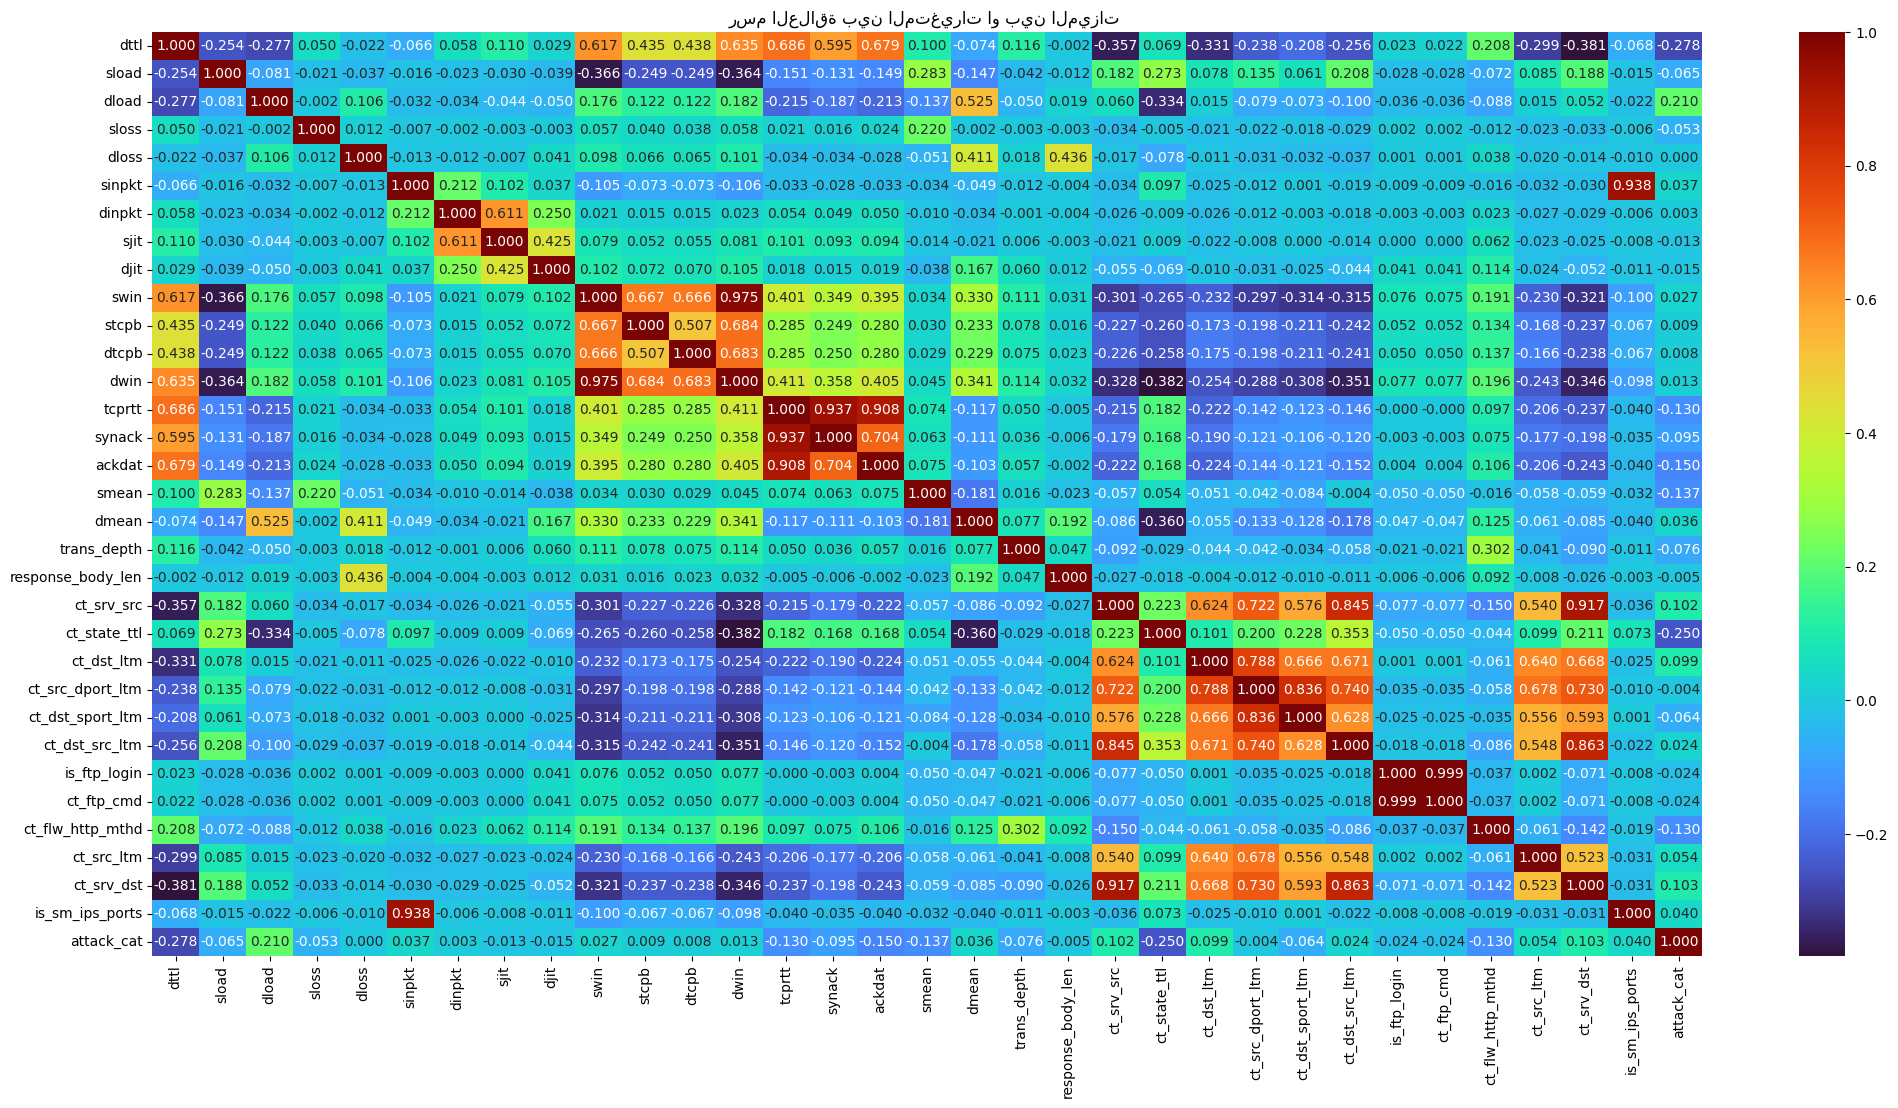

In [15]:
#حساب العلاقة بين المتغيرات او بين الميزات
print("العلاقة بين الميزات وميزة الهدف ")
display(dataset.iloc[:,:43].corr())
print("@"*100)
#رسم العلاقة بين المتغيرات او بين الميزات
print("رسم العلاقة بين المتغيرات او بين الميزات ")

plt.figure(figsize=(25,12))
sns.heatmap(dataset.iloc[:1150000,10:45].corr(),annot=True,fmt=".3f",cmap="turbo")
plt.title("رسم العلاقة بين المتغيرات او بين الميزات ")
plt.show()

## اختيار الميزات أو هندسة الميزات

In [16]:
from sklearn.feature_selection import SelectFromModel

X=dataset.drop(["attack_cat"],axis=1).values
y=dataset.attack_cat.values
#خوارزمية الغابة العشوائية

model=RandomForestClassifier(n_estimators=150,
                             max_depth=15,            #عمق الشجرة
                             min_samples_split=4,     #تحديد العقد النهائية
                             random_state=42          #العشوائية
                             )
selector=SelectFromModel(model)
selector_feature=selector.fit(X,y)

In [17]:
# استخراج الميزات المهمة فقط
X_selected = selector.transform(X)

# معرفة عدد الميزات قبل وبعد الاختيار
print("عدد الميزات قبل الاختيار:", X.shape[1])
print("عدد الميزات بعد الاختيار:", X_selected.shape[1])

# معرفة أسماء الميزات التي تم اختيارها
selected_features = dataset.drop(["attack_cat"], axis=1).columns[selector.get_support()]
print("معرفة أسماء الميزات التي تم اختيارها\n",selected_features)


عدد الميزات قبل الاختيار: 42
عدد الميزات بعد الاختيار: 13
معرفة أسماء الميزات التي تم اختيارها
 Index(['service', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sload', 'dload',
       'smean', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_src_ltm',
       'ct_srv_dst'],
      dtype='str')


### البانات بعد اختيار الميزات

In [ ]:
feature_selected_data=dataset[['service', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sload', 'dload',
       'smean', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_src_ltm',
       'ct_srv_dst']]
print("=================:مجموعة البيانات بعد اختيار الميزات المهمة من مجموعة البيانات الاصلية=======================")
display(feature_selected_data)

=================:مجموعة البيانات بعد اختيار الميزات المهمة من مجموعة البيانات الاصلية=======================


,service,sbytes,dbytes,sttl,dttl,sload,dload,smean,dmean,ct_srv_src,ct_state_ttl,ct_dst_src_ltm,ct_srv_dst
0,0.0,258,172,252,254,1.415894e+04,8495.365234,43,43,1,0,1,1
1,0.0,734,42014,62,252,8.395112e+03,503571.312500,52,1106,43,1,2,6
2,0.0,364,13186,62,252,1.572272e+03,60929.230470,46,824,7,1,3,6
3,3.0,628,770,62,252,2.740179e+03,3358.622070,52,64,1,1,3,1
4,0.0,534,268,254,252,8.561499e+03,3987.059814,53,45,43,1,40,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
257658,0.0,588,268,254,252,4.477112e+03,1892.213501,59,45,4,1,4,4
257660,0.0,588,268,254,252,5.222228e+03,2207.130127,59,45,4,1,4,4
257664,0.0,138067,1042,254,252,2.117719e+05,1546.616211,1278,43,1,1,1,3
257668,0.0,104,0,254,0,8.320000e+07,0.000000,52,0,1,2,2,1


## <span style="color:red"> المرحلة الخامسة:تقسيم البيانات وبنا النموذج </span>

### اولا:تحديد وتقسيم البيانات التدريب والاختبار

In [19]:

x_train,x_test,y_train,y_test=train_test_split(X_selected,y,test_size=0.2,random_state=42)
print("x_train shape :",x_train.shape)
print("x_test shape :",x_test.shape)
print("y_train shape :",y_train.shape)
print("y_test shape :",y_test.shape)



x_train shape : (130196, 13)
x_test shape : (32549, 13)
y_train shape : (130196,)
y_test shape : (32549,)


### :بيانات التدريب 

In [20]:
train_data=pd.DataFrame(x_test,columns=['service', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sload', 'dload',
       'smean', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_src_ltm',
       'ct_srv_dst'])

print("=========================== بيانات التدريب =======================")
display(train_data)

=========================== بيانات التدريب =======================


,service,sbytes,dbytes,sttl,dttl,sload,dload,smean,dmean,ct_srv_src,ct_state_ttl,ct_dst_src_ltm,ct_srv_dst
0,0.0,900.0,642.0,254.0,252.0,8.206395e+03,5.726975e+03,56.0,54.0,6.0,1.0,6.0,7.0
1,5.0,856.0,268.0,254.0,252.0,3.345955e+04,9.721062e+03,86.0,45.0,1.0,1.0,1.0,1.0
2,0.0,734.0,354.0,254.0,252.0,6.606135e+03,3.098188e+03,73.0,44.0,1.0,1.0,1.0,1.0
3,0.0,104.0,0.0,254.0,0.0,2.080000e+08,0.000000e+00,52.0,0.0,4.0,2.0,3.0,3.0
4,2.0,114.0,0.0,254.0,0.0,5.066666e+07,0.000000e+00,57.0,0.0,16.0,2.0,16.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32544,0.0,2766.0,24004.0,31.0,29.0,1.148561e+06,9.974726e+06,63.0,522.0,2.0,0.0,1.0,5.0
32545,0.0,534.0,354.0,254.0,252.0,1.994116e+03,1.285189e+03,53.0,44.0,2.0,1.0,1.0,2.0
32546,5.0,842.0,15818.0,62.0,252.0,2.624540e+04,5.172906e+05,84.0,879.0,1.0,1.0,1.0,1.0
32547,0.0,22038.0,642.0,254.0,252.0,8.308512e+04,2.292138e+03,689.0,54.0,1.0,1.0,1.0,1.0


### :بيانات الاختبار 

In [21]:
test_data=pd.DataFrame(x_test,columns=['service', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sload', 'dload',
       'smean', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_src_ltm',
       'ct_srv_dst'])

print("=========================== بيانات الاختبار =======================")
display(test_data)

=========================== بيانات الاختبار =======================


,service,sbytes,dbytes,sttl,dttl,sload,dload,smean,dmean,ct_srv_src,ct_state_ttl,ct_dst_src_ltm,ct_srv_dst
0,0.0,900.0,642.0,254.0,252.0,8.206395e+03,5.726975e+03,56.0,54.0,6.0,1.0,6.0,7.0
1,5.0,856.0,268.0,254.0,252.0,3.345955e+04,9.721062e+03,86.0,45.0,1.0,1.0,1.0,1.0
2,0.0,734.0,354.0,254.0,252.0,6.606135e+03,3.098188e+03,73.0,44.0,1.0,1.0,1.0,1.0
3,0.0,104.0,0.0,254.0,0.0,2.080000e+08,0.000000e+00,52.0,0.0,4.0,2.0,3.0,3.0
4,2.0,114.0,0.0,254.0,0.0,5.066666e+07,0.000000e+00,57.0,0.0,16.0,2.0,16.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32544,0.0,2766.0,24004.0,31.0,29.0,1.148561e+06,9.974726e+06,63.0,522.0,2.0,0.0,1.0,5.0
32545,0.0,534.0,354.0,254.0,252.0,1.994116e+03,1.285189e+03,53.0,44.0,2.0,1.0,1.0,2.0
32546,5.0,842.0,15818.0,62.0,252.0,2.624540e+04,5.172906e+05,84.0,879.0,1.0,1.0,1.0,1.0
32547,0.0,22038.0,642.0,254.0,252.0,8.308512e+04,2.292138e+03,689.0,54.0,1.0,1.0,1.0,1.0


## <span style="color:red"> المرحة السادسة:التدريب والتقييم </span>

### اولا:اختيار الخوارزمية

In [22]:
#خوارزمية الغابة العشوائية

model=RandomForestClassifier(n_estimators=200,
                             max_depth=15,           #عمق الشجرة
                             min_samples_split=4,     #تحديد العقد النهائية
                             random_state=42         #العشوائية
                             )

### تدريب النموذج

In [23]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### اختبار النوذج باستخدام بيانات الاختبار

In [24]:
prediction=model.predict(x_test)

## <span style="color:red"> المرحلة السابعة:تقييم النموذج </span>

### تقييم النموذج

In [25]:
# حساب تقرير التصنيف الذي يحتوي على Precision و Recall و F1-Score لكل فئة
report = classification_report(y_test, prediction)

# حساب مصفوفة الالتباس (Confusion Matrix)
matrix = confusion_matrix(y_test, prediction)

# حساب دقة النموذج (Accuracy)
accuracy = accuracy_score(y_test, prediction)

# حساب قيمة Precision مع استخدام المتوسط المرجح (Weighted Average)
precision = precision_score(y_test, prediction, average="weighted")

# حساب قيمة F1-Score مع استخدام المتوسط المرجح
f1 = f1_score(y_test, prediction, average="weighted")

# حساب قيمة Recall مع استخدام المتوسط المرجح
recal = recall_score(y_test, prediction, average="weighted")

# عرض تقرير التصنيف
print("Classification Report:\n", report)

# طباعة خط فاصل
print("_" * 100)

# عرض مصفوفة الالتباس
print("Confusion Matrix:\n", matrix)

# طباعة خط فاصل
print("_" * 100)

# عرض قيمة Accuracy
print("Accuracy Score:", accuracy)

# طباعة خط فاصل
print("_" * 100)

# عرض قيمة Precision
print("Precision Score:", precision)

# طباعة خط فاصل
print("_" * 100)

# عرض قيمة F1-Score
print("F1-Score:", f1)

# طباعة خط فاصل
print("_" * 100)

# عرض قيمة Recall
print("Recall Score:", recal)

# طباعة خط فاصل
print("_" * 100)

Classification Report:
               precision    recall  f1-score   support

           0       0.23      0.03      0.05       428
           1       0.27      0.07      0.11       352
           2       0.45      0.23      0.31      1075
           3       0.80      0.86      0.83      5547
           4       0.56      0.62      0.59      4144
           5       0.97      0.86      0.91      1534
           6       0.91      0.94      0.92     17112
           7       0.84      0.75      0.79      2040
           8       0.59      0.64      0.61       284
           9       0.56      0.15      0.24        33

    accuracy                           0.82     32549
   macro avg       0.62      0.52      0.54     32549
weighted avg       0.81      0.82      0.81     32549

____________________________________________________________________________________________________
Confusion Matrix:
 [[   13    11    44    44   214     0    79    21     2     0]
 [    4    25    44    51   185   

### رسم اول شجرة داخل الغابة العشوائية

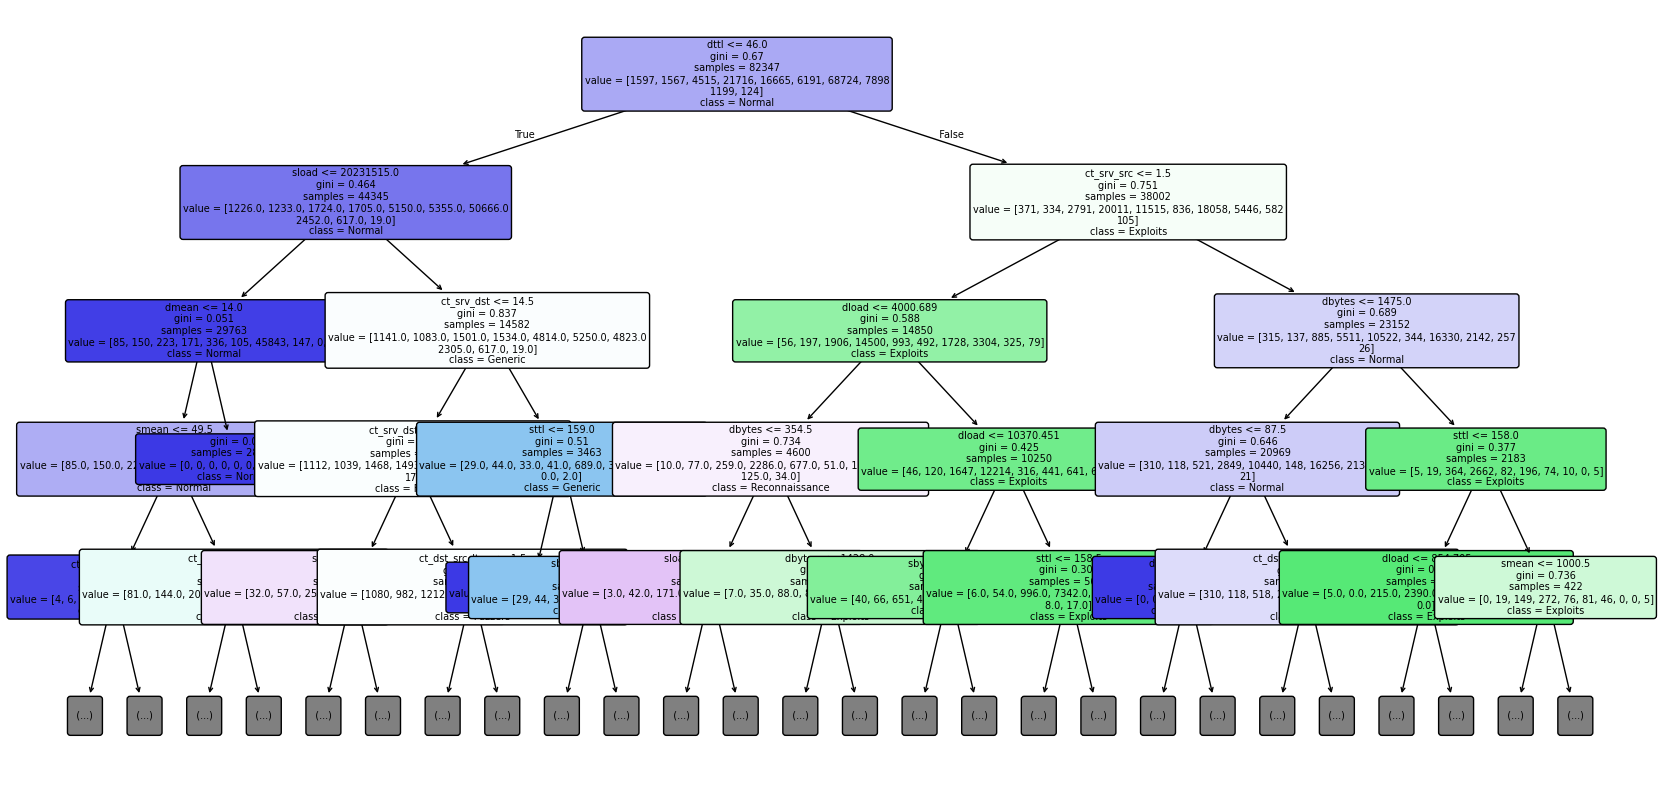

In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# استخراج أول شجرة من الغابة العشوائية
first_tree = model.estimators_[0]

# إنشاء مساحة الرسم
plt.figure(figsize=(20, 10))

# رسم أول شجرة
plot_tree(
    first_tree,
    filled=True,                    # تلوين العقد حسب الفئة
    feature_names=selected_features, # أسماء الميزات المستخدمة
    class_names=encoder.classes_,  # أسماء الفئات
    rounded=True,
    max_depth=4 ,                 # جعل العقد مستديرة
    fontsize=7                  # حجم الخط
)

plt.show()

## دالة التوقع من البيانات الجديدة

<div dir="rtl"></div>

In [27]:

# # تحميل أداة التشفير المحفوظة
# دالة التنبؤ
def predict_attack(values):
    # تحويل القيم إلى مصفوفة بالشكل المطلوب
    values = np.array(values).reshape(1, -1)

    # الحصول على رقم الفئة المتوقعة
    prediction = model.predict(values)

    # تحويل الرقم إلى اسم الهجوم الأصلي
    attack_name = encoder.inverse_transform(prediction)
    predict_probability=model.predict_proba(values)
    return attack_name[0],predict_probability

n=x_test[5000]

# إدخال 42 قيمة بنفس ترتيب أعمدة التدري
sample =[

    0.00000000e+00,          # service
    5.64000000e+02,          # sbytes
    3.54000000e+02,          # dbytes
    2.54000000e+02,          # sttl
    2.52000000e+02,          # dttl
    3.06849902e+03,          # sload
    1.87250928e+03,          # dload
    5.60000000e+01,          # smean
    4.40000000e+01,          # dmean
    1.00000000e+00,          # ct_srv_src
    1.00000000e+00,          # ct_state_ttl
    1.00000000e+00,          # ct_dst_src_ltm
    4.00000000e+00           # ct_srv_dst
]
# التنبؤ
prediction,predict_proba = predict_attack(sample)

print(f"{prediction}:الهجوم المتوقع")
max_proba=np.max(predict_proba.round(5))*100
print( f"{max_proba}        :بنسبة تنبؤ")


Reconnaissance:الهجوم المتوقع
97.598        :بنسبة تنبؤ


<div dir="rtl">


# الاستنتاج
أظهر نموذج **Random Forest Classifier** أداءً جيدًا في تصنيف أنواع الهجمات، حيث حقق **دقة (Accuracy) بلغت 82.57%**، مع **Precision = 80%** و**Recall = 81.57%** و**F1-Score = 80.33%**. تشير هذه النتائج إلى قدرة النموذج على تصنيف معظم الهجمات بشكل صحيح، خاصةً الفئات ذات العدد الكبير من العينات، بينما انخفض الأداء في بعض الفئات التي تحتوي على عدد قليل من العينات، كما يتضح من قيم الـ Precision والـ Recall المنخفضة لها. وبشكل عام، يمكن اعتبار النموذج ناجحًا وفعالًا في اكتشاف وتصنيف الهجمات، مع إمكانية تحسين أدائه على الفئات النادرة من خلال معالجة عدم توازن البيانات أو ضبط معاملات النموذج.
</div>